<a href="https://colab.research.google.com/github/ChristianParsons98/PG_Lab_Code/blob/main/Full_Set_Na3PS4_Raman_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pybaselines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
from sympy import init_printing
init_printing(use_latex=True)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp
import pandas as pd
import math
import scipy
from scipy.stats import chisquare
print(scipy.__version__)
from scipy.optimize import leastsq
from scipy.special import voigt_profile
from sklearn.metrics import r2_score
import csv
from scipy.signal import find_peaks
from pybaselines import Baseline

# This document is used to Find the Center and FWHM of Raman Peaks
# Uses the file 'Sample.PRN' to plot Raman Peaks

#This document attempts a rewrite of the code to find Raman Peaks.


1.16.3


In [ ]:
# # This is the code which compiles all the files into a single csv
# # Some amount of renaming is required here.
# # Importing the Results for NPS

# dfs = []
# # /1NPS3-26.PRN
# for i in range(1, 11):
#     file_path = f"/content/{i}NPS3-26.PRN"

#     df = pd.read_csv(
#         file_path,
#         delimiter='\t',
#         header=None,
#         names=[f'wavenumber_{i}', f'intensity_{i}']
#     )

#     dfs.append(df)

# df_final = pd.concat(dfs, axis=1)

# df_final.to_csv('AllRaman.csv')

In [ ]:
#Import the compiled data
#Need to skip the footer here as the footer is a string end file character.
df_final = pd.read_csv('/content/AllRaman.csv',index_col=0,dtype=np.float64,skipfooter=1)
#df_final.head()

/tmp/ipykernel_1123/1055047368.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df_final = pd.read_csv('/content/AllRaman.csv',index_col=0,dtype=np.float64,skipfooter=1)


In [ ]:
#Here I am applying baseline correction using ASLS.
#I am also normalizing such that the largest peak is equal for each (1701 for Enterprise NCC-1701-D).
for i in range(1, 11):
    wn_col = f"wavenumber_{i}"
    int_col = f"intensity_{i}"
    corr_col = f"corrected_{i}"

    # Drop NaNs (important if column lengths differ)
    mask = df_final[wn_col].notna() & df_final[int_col].notna()

    x = df_final.loc[mask, wn_col].values
    y = df_final.loc[mask, int_col].values

    # Baseline correction
    baseline_fitter = Baseline(x_data=x)
    baseline, _ = baseline_fitter.asls(y, lam=1e5, p=0.01, max_iter=20)

    corrected = y - baseline

    # Scale so max = 1701
    if np.max(corrected) != 0:
        corrected = corrected / np.max(corrected) * 1701

    # Insert back into dataframe (aligned with original indices)
    df_final.loc[mask, corr_col] = corrected

In [ ]:
df_final.head()

,wavenumber_1,intensity_1,wavenumber_2,intensity_2,wavenumber_3,intensity_3,wavenumber_4,intensity_4,wavenumber_5,intensity_5,...,corrected_1,corrected_2,corrected_3,corrected_4,corrected_5,corrected_6,corrected_7,corrected_8,corrected_9,corrected_10
0,99.169,12651.0,99.169,14655.0,99.206,4402.0,99.169,13814.0,99.169,7488.8,...,-67.981209,174.557581,-20.192883,72.868306,46.288126,138.377303,-132.358997,126.961511,-8.192561,11.494305
1,100.240,13177.0,100.240,14784.0,100.280,4583.1,100.240,14090.0,100.240,7488.8,...,104.387309,188.306153,30.217977,98.741585,47.300674,163.622725,18.353629,142.493679,-16.345273,24.476635
2,101.320,13846.0,101.320,14717.0,101.360,4690.2,101.320,14435.0,101.320,7390.3,...,324.551176,182.889165,59.526701,130.969994,37.095248,168.230197,77.444233,143.669621,-11.418427,35.099689
3,102.390,13771.0,102.390,14665.0,102.430,4842.2,102.390,14758.0,102.390,7447.5,...,296.050376,178.938873,101.639807,161.172103,44.622171,182.653229,210.080601,142.077284,10.558776,33.858959
4,103.470,13689.0,103.470,14769.0,103.510,4898.9,103.470,14727.0,103.470,7433.5,...,265.211943,190.242681,116.577114,158.769542,44.040240,185.163214,203.281720,154.362847,43.851444,45.257187


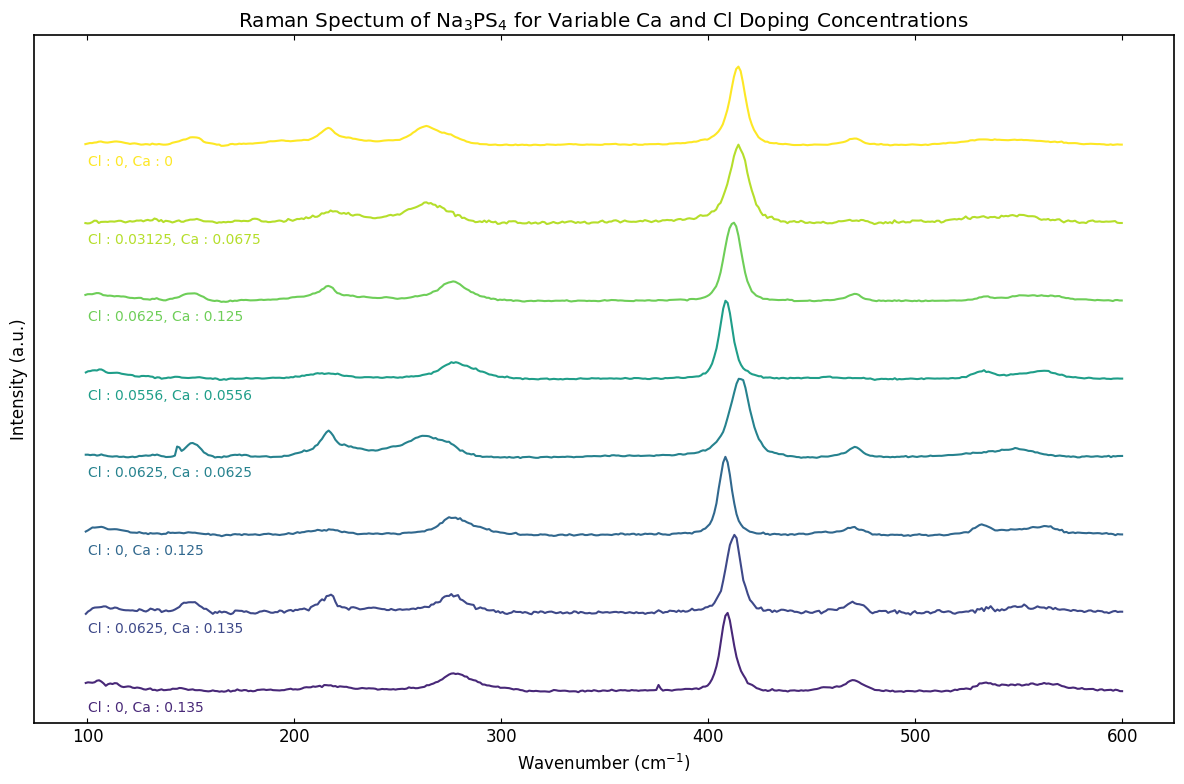

In [ ]:
# Make a list of the Ca/Cl values where the sample number is index+1
label_lst=["Cl : 0.0625, Ca : 0", "Cl : 0, Ca : 0.135", "Cl : 0.0625, Ca : 0.135", "Cl : 0, Ca : 0.125",
 "Cl : 0.0625, Ca : 0.0625", "Cl : 0.0556, Ca : 0.0556", "Cl : 0.03125, Ca : 0.135", "Cl : 0.0625, Ca : 0.125",
 "Cl : 0.03125, Ca : 0.0675","Cl : 0, Ca : 0"]

# Samples to skip
skip = {1, 7}

# Plot Style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, 10))

offset = 1701

plot_idx = 0  # new compact index

for i, color in zip(range(1, 11), colors):

    if i in skip:
        continue  # skip samples 1 and 7

    wn = df_final[f"wavenumber_{i}"]
    intensity = df_final[f"corrected_{i}"]

    mask = wn.notna() & intensity.notna()
    wn_clean = wn[mask]
    int_clean = intensity[mask]

    #Helping to make nice plots when all 10 are not there.
    y_offset = int_clean + plot_idx * offset

    ax.plot(
        wn_clean,
        y_offset,
        color=color,
        linewidth=1.5
    )

    ax.text(
        wn_clean.iloc[1],
        y_offset.iloc[-1] - 370,
        label_lst[i-1],
        color=color,
        fontsize=10,
        va="center",
        ha="left"
    )

    plot_idx += 1  # increment only for plotted spectra

# Labels
plt.title("Raman Spectum of Na$_3$PS$_4$ for Variable Ca and Cl Doping Concentrations")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity (a.u.)")

ax.set_yticks([])

plt.tight_layout()
plt.savefig("FullRamanSpectra_SubSet.png", dpi=600)
plt.show()



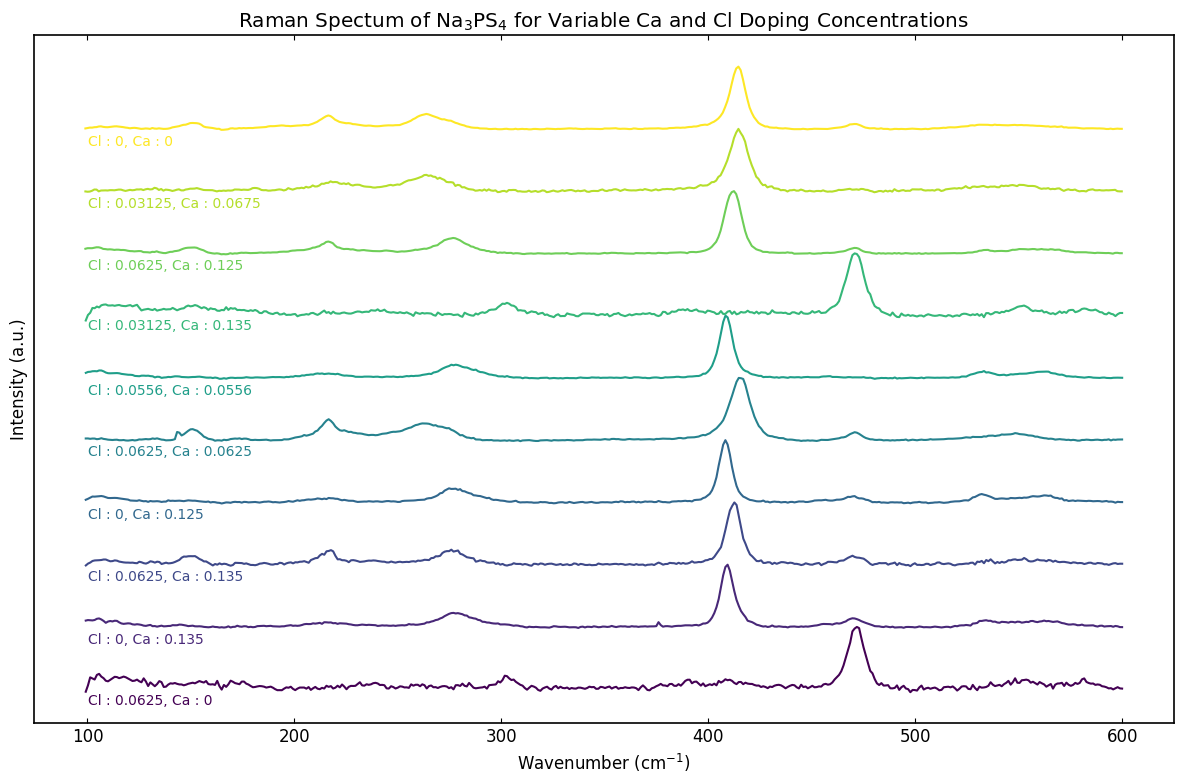

In [ ]:
#This is for when all of the data looks good.
# Make a list of the Ca/Cl values where the sample number is index+1
label_lst=["Cl : 0.0625, Ca : 0", "Cl : 0, Ca : 0.135", "Cl : 0.0625, Ca : 0.135", "Cl : 0, Ca : 0.125",
 "Cl : 0.0625, Ca : 0.0625", "Cl : 0.0556, Ca : 0.0556", "Cl : 0.03125, Ca : 0.135", "Cl : 0.0625, Ca : 0.125",
 "Cl : 0.03125, Ca : 0.0675","Cl : 0, Ca : 0"]


# Plot Style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, ax = plt.subplots(figsize=(12, 8))

# Set the colormap here. Try Viridis
colors = plt.cm.viridis(np.linspace(0, 1, 10))

offset = 1701  # vertical spacing between spectra

for i, color in zip(range(1, 11), colors):
    wn = df_final[f"wavenumber_{i}"]
    intensity = df_final[f"corrected_{i}"]

    # Remove NaNs
    mask = wn.notna() & intensity.notna()
    wn_clean = wn[mask]
    int_clean = intensity[mask]

    y_offset = int_clean + (i - 1) * offset

    # The actual plotting of the line
    ax.plot(
        wn_clean,
        y_offset,
        color=color,
        linewidth=1.5
    )

    # Adding labels as text. A legend does not look very nice with this many stacked plots.
    ax.text(
        wn_clean.iloc[1],              # leftmost x
        y_offset.iloc[-1]-350,             # corresponding y
        #f"Sample #{i}",
        label_lst[i-1],
        color=color,
        fontsize=10,
        va="center",
        ha="left"
    )

# Axis Labels
plt.title("Raman Spectum of Na$_3$PS$_4$ for Variable Ca and Cl Doping Concentrations")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity (a.u.)")


# Removing the ticks looks better.
ax.set_yticks([])

plt.tight_layout()
plt.savefig("FullRamanSpectra.png", dpi=600)
plt.show()



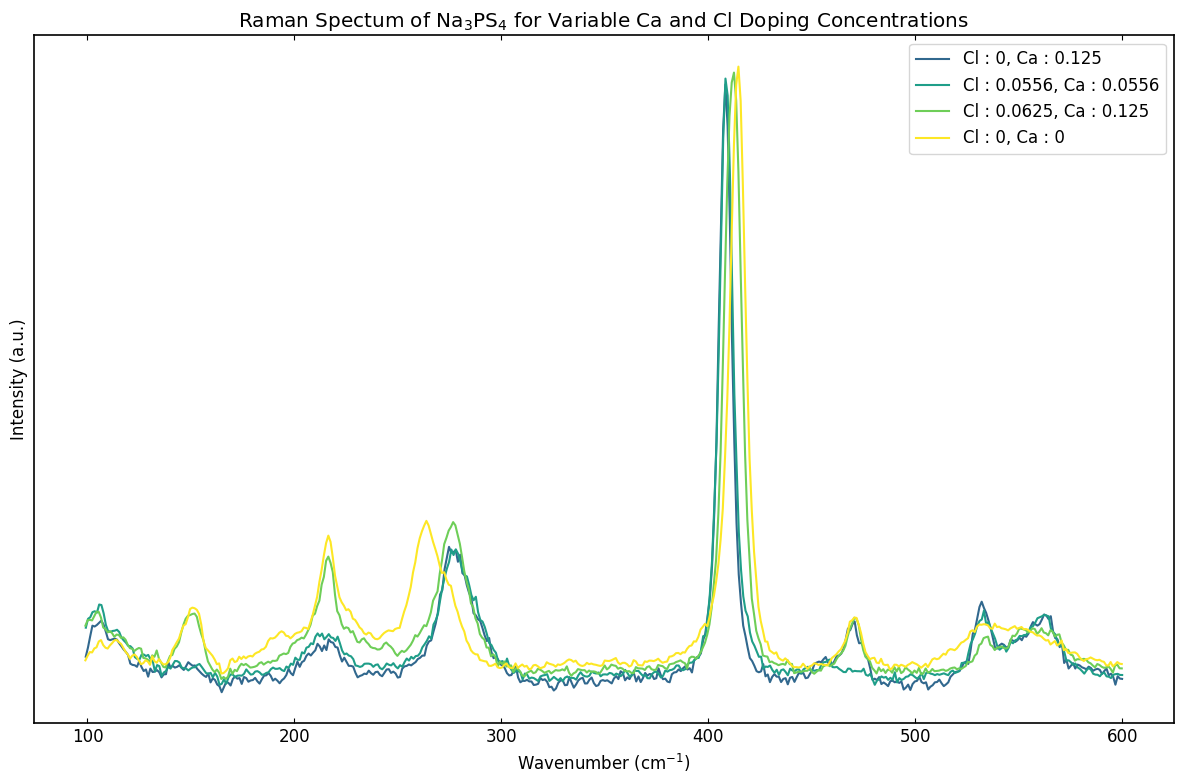

In [ ]:
# Make a list of the Ca/Cl values where the sample number is index+1
label_lst=["Cl : 0.0625, Ca : 0", "Cl : 0, Ca : 0.135", "Cl : 0.0625, Ca : 0.135", "Cl : 0, Ca : 0.125",
 "Cl : 0.0625, Ca : 0.0625", "Cl : 0.0556, Ca : 0.0556", "Cl : 0.03125, Ca : 0.135", "Cl : 0.0625, Ca : 0.125",
 "Cl : 0.03125, Ca : 0.0675","Cl : 0, Ca : 0"]

# Samples to skip
skip = {1,2, 7, 3,5,9}

# Plot Style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, 10))

offset = 17.01

plot_idx = 0  # new compact index

for i, color in zip(range(1, 11), colors):

    if i in skip:
        continue  # skip samples 1 and 7

    wn = df_final[f"wavenumber_{i}"]
    intensity = df_final[f"corrected_{i}"]

    mask = wn.notna() & intensity.notna()
    wn_clean = wn[mask]
    int_clean = intensity[mask]

    #Helping to make nice plots when all 10 are not there.
    y_offset = int_clean + plot_idx * offset

    ax.plot(
        wn_clean,
        y_offset,
        color=color,
        linewidth=1.5,
        label=label_lst[i-1]
    )


    plot_idx += 1  # increment only for plotted spectra

# Labels
plt.title("Raman Spectum of Na$_3$PS$_4$ for Variable Ca and Cl Doping Concentrations")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity (a.u.)")

ax.set_yticks([])
plt.legend()
plt.tight_layout()
plt.savefig("Raman_Comparison.png", dpi=600)
plt.show()

